Ion Beam
========

In a collisionless plasma, more than one population of protons may coexist at one given place (the same may happen for electrons but obviously not in a hybrid code where electrons are treated as a ﬂuid).
In a collisional plasma such a coexistence is not possible as collisions immediately thermalize all populations into a single one.
In this Practical Training, we address the question of the stability of two populations of protons streaming one respect to the other along the local magnetic ﬁeld, a situation often encountered in collisionless plasmas.
As we shall see, nature and strength of the instability varies with the plasma parameters (density, magnetic ﬁeld strength, relative velocity, temperature, ... ).

In general, an instability arises if a mode exists with phase speed such as to be able to increase its amplitude by taking the kinetic energy from the beam particles.
For this to happen, phase velocity and beam velocity must be quasi-equal in which case the mode is said to resonates with the beam.

In [1]:
import os
import sys
from pathlib import Path

try: # notebooks has no __file__
    WORK_DIR  = Path(__file__).parent 
except NameError:
    WORK_DIR  = Path(os.getcwd()) 
PROJECT_DIR = Path(WORK_DIR).parent.parent.parent.parent.parent
work_path = str(WORK_DIR)

In [2]:
paths = [str(PROJECT_DIR/s) for s in ["", "build", "pyphare"]]
sys.path.extend(paths)
os.environ['PYTHONPATH'] = os.pathsep.join(paths) + os.pathsep + os.environ.get('PYTHONPATH', "")

In [3]:
import numpy as np
from numpy import polyfit
import subprocess
import matplotlib.pyplot as plt
from pyphare.pharesee.run import Run
import pyphare.pharesee as phc
from pyphare.pharesee.hierarchy import uniformgrid as uniform
from pyphare.core.operators import dot, cross, sqrt, modulus, grad

# Electrostatic case

A particular example of beam instability is the one involving the ion-acoustic mode.
The ion acoustic mode is a plasma equivalent of the standard acoustic mode in a compressible gas.
Its phase speed is $(\omega/k)2 = c_s^2=(T_e + 3T_p)/m_p$ in proton-electron plasma.
The very fact that the phase speed does not depend on the magnetic ﬁeld, suggest that the mode is a purely electrostatic one, not associated with ﬂuctuations of the magnetic ﬁeld.
As already anticipated a beam of protons is potentially unstable if the phase speed of a plasma mode is roughly the same as the beam
velocity.
To be more precise, a mode can grow (and be unstable) if its phase speed falls in the velocity interval where the slope of the beam distribution function is positive as depicted in the next scheme for the case of the ion acoustic mode with phase speed $\omega/k = c_s$.

In this example (where the magnetic ﬁeld plays no role) the condition for instability is $\omega/k = c_s \sim U_b$ where $U_b$ is the bulk velocity of the beam.
Stated diﬀerently $\omega/k -U_b \sim 0$.
On average, beam particles will loose kinetic energy (by moving towards the core) which is transferred to the wave.
We call **core** the resting dense plasma with a null bulk velocity and a density $n_c=1$.
We call **beam** the tenuous drifting population with a density $n_b \ll n_0$ and a bulk velocity $U_b$.

The plasma parameters for the simulation **a** are

$U_b = 0.7, \quad T_e = 0.2, \quad T_c = 0.02, \quad  T_b = 0.02, \quad n_b = 0.1$

The density and pressure of the beam are 1/10 of the values in the core which implies that the ion acoustic propagation speed is essentially given by the core plasma, i.e. $c_s = \sqrt{T_e+3T_c}$.

Note that in the simulation (in order to improve statistics for the beam particles) the same number of particles has been used for core and beam.
Given that $n_b / n_c = 0.1$, the statistical weight of a core particle is 10 times that of a beam particle.
In order to understand the physics at play, you will have to plot the structure of the phase space ($x, u$), using two different colors for the core and the beam, a slice of this distribution at a given $x$ location, the associated profile of the longitudinal electric field.

## Sample questions

1. Estimate the linear growth rate $\gamma$ of the instability. Give the wavelength $\lambda$ of the dominant mode.
2. Try to observe the deformation of the proton distribution function during the linear phase of the instability.
3. What happens during the non-linear phase of the instability (trapping of particles by the electric ﬁeld) ?
4. any suggestions of questions ?

## Physical interpretation of the electrostatic ion-beam instability

Let us assume that, as a result of the statistical fluctuations an ion acoustic mode with a wave vector $k = 2\pi/ \lambda$ appears in the core-beam system.
The mode being a purely electrostatic one, it can be shown that the electrostatic field ﬂuctuation $\phi_1$ and the density ﬂuctuation $n_1$ must vary spatially in phase.
Let us then ask, if the wave which propagates at a speed $c_s = \omega/k$ is compatible with an exponential growth in time at the rate $\gamma$.
To answer the question we verify whether or not some of the natural density ﬂuctuations $n_1$ which are naturally
present in the system grow exponentially in time out of the initial noise.
If yes the mode is unstable.

It is important to realize that given the (a priori unknown) grow rate $\gamma$ and the wave vector $k$, two categories of particles exist.
The resonant particles, with $|v-c_s| < \gamma/k$, and the circulating (or ballistic) particles.
The circulating particles are moving suﬃciently fast with respect to the wave so that during the characteristic growth time of the
instability $\gamma^{-1}$ they travel a distance larger than $\lambda$.
On average the velocity of these particles is unchanged as they have traveled through a spatially oscillating electrostatic potential with no net gain of energy.
On the other hand, during the same time interval $\gamma^{-1}$, the resonant particles travel over a distance smaller than $\lambda$ and either gain or loose kinetic energy depending on whether they are located in a trough or a bump of the electrostatic potential $\phi(x)$.

The evolution of the beam velocity distribution function in electrostatic field of a growing ion acoustic wave with phase speed located in the region of positive $\partial_u f > 0$ is shown below.
In a deepening potential trough, resonant particles constantly increase their velocity implying a shifting of the distribution towards
higher velocities.
On the other hand, in a growing potential bump, resonant particles constantly decelerate and the distribution shifts towards lower
velocities.
As a consequence, the density increase in potential bumps and decreases in potential troughs further accentuating the initial density fluctuation: the conﬁguration is unstable.
If the phase velocity of the wave is located in the region with $\partial_u f < 0$, the density evolution in troughs and bumps would be such as to reduce (damp) the initial ﬂuctuation: the conﬁguration is stable.

# Electromagnetic case

In this example, as for run **a**, we consider the case of a beam of protons streaming along
a magnetic ﬁeld line $\mathbf{B}_0 = B_0 \hat{\mathbf{x}}$ where $\hat{\mathbf{x}}$ is the unit vector in the $x$ direction.
As in the case **a**, an instability arises if there is a plasma mode which can resonate with the beam.
Here, however, we do now consider a combination of plasma and beam parameters such as to drive unstable either the Alfvén Ion Cyclotron (AIC) mode
or the magnetosonic whistler (MW) mode.

In the next figure the dispersion relations for the AIC and the MW modes are plotted in the cold plasma limit, i.e. for $\beta \ll 1$ which is fine here.

For small values of $k$ (long wavelength) both the AIC dispersion and the MW dispersion merge with the Alfvén mode $\omega/k = \pm v_A$.
As $k$ increases the phase speed $\omega/k$ decreases for the AIC while it increases for the MW (the modes become dispersive).
The characteristic spatial and temporal scales at which the phase velocity of the two modes separate are of the order $v_A / \Omega_p$ and $\Omega_p^{-1}$, respectively (where $\Omega_p = eB_0 /m_p$ is the proton angular frequency).

Again, as for the case **a**, the beam is instable only possible if there is a plasma mode such that the resonance condition can be satisﬁed
$$
\omega +m \Omega_p \sim k U_b
$$
where $m \in \mathbb{R}$ is an integer number ($m = 0$ in the electrostatic case **a**).
The resonance curves for $m = \pm1$ are plotted above for a beam with $U_b = 3v_A$ showing that the resonance curve $m = +1$ crosses the AIC and MW for $kv_A / \Omega_p \sim \pm 0.5$

The instability of the beam in run **b** can be explored by plotting both the $y$ and $z$ components of the magnetic field.
The polarisation of this mode can straightforwardly be deduced, and also confirm by plotting an hodogram.

You can also check the distribution function for all protons (beam and core) for the run **b**, in the phase space ($v_x; v_z$).
You can check that the situation is quite gyrotrop, so that this structure is quite the same in the phase space ($v_x; v_y$).
Interestingly, the beam particles tend to describe a circular arc centered on the phase velocity of the wave.

## Sample questions

1. Measure the propagation speed of the wave and the growth rate of the instability.
2. Is the unstable wave an AIC or a MW wave ?
3. What is the polarization of the wave in the plasma frame (essentially the simulation frame), i.e. does the magnetic field rotate clockwise or anticlockwise when looking in the direction of the propagating wave ?
4. What is the phase speed of the unstable mode required to satisfy the resonance condition with $m = +1$ ? Why is the resonance condition diﬀerent with respect to the electrostatic case **a** ?
5. Verify that in the frame of the resonating particle the wave rotates in phase with the protons.
6. In the ($v_x; v_z$) phase space, the beam particles describe an arc. Can you comment on this by considering that

## Derivation and general properties of the MW and AIC waves

The main characteristics of both the MW and the AIC modes can be obtained relatively easily in the cold plasma limit.
At large scales, i.e. for $k \to 0$, both modes propagate at the Alfvén speed.
However, at scales of the order of the proton inertial scale $v_A / \Omega_p$ and the proton gyration period $\Omega_p^{-1}$, a drift of the protons with respect to the electrons becomes possible in the direction perpendicular to the magnetic field lines.
At these scales both modes become dispersive.
The relative drift of the protons with respect to the electrons in the direction perpendicular to $B$ is called the Hall eﬀect.
In order to account for the Hall eﬀect, an additional, current dependent term, has to be added in Ohm's law:
$$
\mathbf E = - \mathbf U \times \mathbf B + \frac{1}{en} \mathbf J \times \mathbf B
$$

where $\mathbf U$ is the mean velocity of the plasma (but also of the protons as $m_e = 0$) and
$U_e$ the mean velocity of the electrons which can only move along the magnetic ﬁeld
lines, so that $\mathbf J = e n (\mathbf U - \mathbf U_e$).
It should also be noted that the ideal term $-\mathbf U \times \mathbf B$ is frame dependent while the Hall term is not.

Assuming a plasma equilibrium with a magnetic ﬁeld pointing in the $x$ direction, $\mathbf{B}_0 = B_0 \hat{\mathbf{x}}$ and a proton density $m_p n_0$ we write the fluid equations for the fluctuating quantities (labeled 1):
\begin{eqnarray}
\mathbf E_1 & = & - \mathbf U_1 \times \mathbf B_0 + (1/en_0) \mathbf J_1 \times \mathbf B_0 \\
n_0 m_p \partial_t \mathbf u_1 & = & \mathbf J_1 \times \mathbf B_0 \\
\partial_t \mathbf B_1 & = & - \boldsymbol{\nabla} \times \mathbf E_1 \\
\mathbf J_1 & = & \boldsymbol{\nabla} \times \mathbf B_1 \\
\end{eqnarray}

We assume one-dimensional ﬂuctuations $\exp [\imath (k x - \omega t)]$ and incompressible fluctuations so that $u_1 = 0$ and $\mathbf B_1 = 0$.
After some algebra work (noting that $\partial_t = - \imath \omega$ and $\boldsymbol{\nabla} \times = + \imath k$), we obtain the dispersion relation for the MW ("+" sign) and the AIC ("-" sign) propagating modes:
$$
\omega = \frac{1}{2} k (k \pm \sqrt{4+k^2})
$$
where $\omega$ is normalized to $\Omega_p$ and $k$ is normalized to $v_A/\Omega_p$.
The $\pm$ sign corresponds to the MW and the AIC mode, respectively.
The equation shows that for $k \to 0$ one has $\omega/k = \pm v_A$, i.e. both modes propagate at the Alfvén speed in the long wavelength limit.

The two solutions are plotted in the following figure

An interesting conclusion can be deduced from the Faraday equation which implies that for the two modes we have
$$
\frac{\omega}{k} \frac{\mathbf B_1}{B_0} = \mathbf B _0 \times \mathbf E_1
$$
and therefore (since $\omega$ is real) that electric and magnetic field fluctuate perpendicularly to each other and that $\mathbf B_1$ and $\mathbf E_1$ are constant which implies circular polarization, e.g. $B_{1y} = \pm \imath B_{1z}$.
In this context, we note that wave polarization is often deﬁned as $P = B_{1y} / \imath B_{1z} = \pm 1$, the sign indicating the sense of rotation of the magnetic ﬁeld in the plasma frame.
With this deﬁnition, it turns out that the MW mode corresponds to the case $P = +1$ (right-handed) and the AIC to $P = -1$ (left-handed).
The other interesting consequence of the above equation is that the electric ﬁeld ﬂuctuation vanishes in the wave frame (can you show it ?).

From Ampère's equation it also follows that the current fluctuates parallel or antiparallel to $\mathbf B_1$ depending on the polarization, i.e.
$$
\mathbf J_1 = - P k \mathbf B_1
$$

From Ohm's law and Faraday's equation it follows that the velocity ﬂuctuation is
$$
\mathbf U_1 = - \left( P \frac{k v_A^2}{\Omega_p} + \frac{\omega}{k} \right) \frac{\mathbf B_1}{B_0}
$$
indicating that the ﬂuid oscillates in opposition to the magnetic ﬁeld for the MW mode (for which $P, \omega > 0$) whereas $\mathbf U_1$ and $\mathbf B_1$ oscillate in phase for the AIC mode (for which $P, \omega < 0$).

It should be noted that in the above calculation $\omega$ is real, a consequence of the cold plasma assumption.
In a mild or warm plasma, when approaching $k \sim 1$, $\omega$ develops a negative imaginary part for both modes corresponding to wave damping.
In particular, at $k > 0.5$, because of a $m = -1$ resonance, the AIC mode is generally heavily damped.

## Triggering the ion-beam instability

Under favorable circumstances, a beam of ions drifting along the magnetic ﬁeld with respect to a population of resting ions can amplify one of the two electromagnetic modes discussed above.
As already mentioned earlier a wave may grow in time through the conversion of the kinetic energy contained in the distribution function to wave energy.
A possible favorable circumstance is resonance involving a mode of the plasma (for example the MW or the AIC) and the protons of the
beam as illustrated above.
However, the fact that a plasma mode with given $\omega$ and $k$ satisﬁes to the resonance condition may not be a suﬃcient condition for the mode to be able to extract the energy from the beam particles.
For example, the $m = +1$ resonance condition crosses the dispersion curve of both the MW and the AIC mode but, as we have seen in the simulation, only one of the two modes has been destabilized by the beam.
The fundamental reason is polarization.
As discussed earlier, in the plasma frame (which is essentially the frame of the core population if the beam density is small), the magnetic field vector or the electric ﬁeld vector are right-handed for the MW mode and left-handed for the AIC mode meaning that for an observer at a ﬁxed position the sense of rotation of the electric ﬁeld is opposite for the two modes.
Now, an eﬃcient energy exchange between the wave and the beam particles can only take place if the resonant particles
experience a net acceleration (or deceleration) in the rotating electric field.
For example a proton traveling with the wave conserves its energy as for both the MW and the AIC the electric ﬁeld vanishes in the wave frame.
This is the reason for the resonance condition $\omega/k \sim U_b$ not to be the pertinent one as for the electrostatic.
Remembering that the electric ﬁeld of the MW and the AIC modes is perpendicular to B0 and that protons make a left-handed rotation about $\mathbf B_0$ one deduces that for the beam particles to constructively resonate with the wave they must see the wave electric field to make a left-handed rotation about $\mathbf B_0$ in their own frame, i.e. in the beam frame.






Let us consider the MW wave which is right-handed in the plasma rest frame.
A proton traveling in the direction of propagation of the wave (i.e. in the direction of $k$ or $B_0$) at a speed lower that the wave speed $\omega/k$ it will see the electric ﬁeld of the wave rotate against its proper cyclotron rotation.
A proton traveling at
$v > \omega/k$ will see the wave ﬁeld make a left-handed rotation.
A proton traveling at $v = (\omega+\Omega_p)/k$ sees the wave ﬁeld rotate at the angular velocity $\Omega_p$ and becomes accelerated perpendicularly to $\mathbf B_0$ (and $\mathbf B_1$) at a rate $\mathrm{d}_t v = e E_1 / m$ where $E_1 = \Omega_p B_1 /k$ is the wave field.
The coherent acceleration of the beam protons in the direction perpendicular to $B_1$ is illustrated ??? for the case of a core-beam plasma with a core temperature 4 times larger than the beam temperature.

It must be noted that the core particles do experience an electric ﬁeld of amplitude $B_1 \omega /k$ (in the direction opposite of that of the beam particles) but the ﬁeld is a fluctuating one which averages to zero so that the core protons oscillate in velocity
with no net gain of energy.
The growth of $v_{\perp}$ for the beam protons averaged over several wavelength is shown in Figure ???.

The figure allows for a rough insight into the physical mechanism of the instability.
First: beam protons are coherently accelerated by the wave electric ﬁeld in the direction perpendicular to $B_1$.
At the same time the core protons are accelerated in the opposite direction.
Second: due to curvature of the ﬁeld lines, part of this increase in transverse velocity becomes field aligned (as shown in see Figure ???) so as to increase $u_1$ and, consequently, the wave amplitude.

In [4]:
U0 = 5
Te = 0
Ti = np.sqrt(0.1)
run_name = "beam"
run_path = os.path.join(work_path, run_name)

In [5]:
files = []
if os.path.isdir(run_path):
    files = os.listdir(run_path)

In [6]:
if 'EM_B.h5' not in files:
    os.chdir(work_path)
    subprocess.run(['mpirun', '-n', '2', 'python3', '-Ou', work_path+'/beam.py', run_name, str(U0), str(Te), str(Ti)], env=os.environ)

In [7]:
run  = Run(run_path)

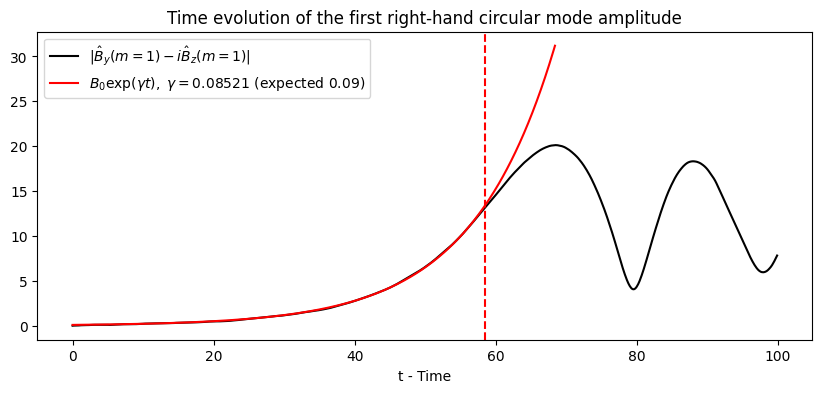

In [8]:
from pyphare.pharesee.hierarchy.fromh5 import get_times_from_h5

def yaebx(x, a, b):
    return a * np.exp(np.multiply(b, x))

def growth_b_right_hand(run_path, time_offset):
    from scipy.optimize import curve_fit

    file = os.path.join(run_path, "EM_B.h5")
    times = get_times_from_h5(file)
    dt = times[1] - times[0]
    r = Run(run_path)
    first_mode = np.array([])
    for time in times:
        B = r.GetB(time, all_primal=False)
        b = B.finest()
        by_grid = b['y']
        bz_grid = b['z']
        nb = by_grid.ghosts_nbr[0]
        sel = slice(nb or None, -nb or None)
        by = np.asarray(by_grid[:])[sel][:-1]
        bz = np.asarray(bz_grid[:])[sel][:-1]
        first_mode = np.append(first_mode, np.absolute(np.fft.fft(by - 1j * bz)[1]))
    ioffset = int(time_offset / dt)
    imax = np.argmax(first_mode)
    popt, _ = curve_fit(
        yaebx, times[:imax - ioffset], first_mode[:imax - ioffset], p0=[0.08, 0.09]
    )
    return times, first_mode, popt[0], popt[1], imax

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
time_offset = 10.0
times_all, first_mode, ampl, gamma, imax = growth_b_right_hand(run_path, time_offset)

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title("Time evolution of the first right-hand circular mode amplitude")
ax.plot(times_all, first_mode, color="k",
        label=r"|$\hat{B}_y(m=1)-i\hat{B}_z(m=1)$|")
ax.plot(times_all[:imax], yaebx(times_all[:imax], ampl, gamma), color="r",
        label=r"$B_0\exp(\gamma t),\ \gamma={:.5f}$ (expected 0.09)".format(gamma))
ax.axvline(times_all[imax] - time_offset, color="red", linestyle="--")
ax.set_xlabel("t - Time")
ax.legend()

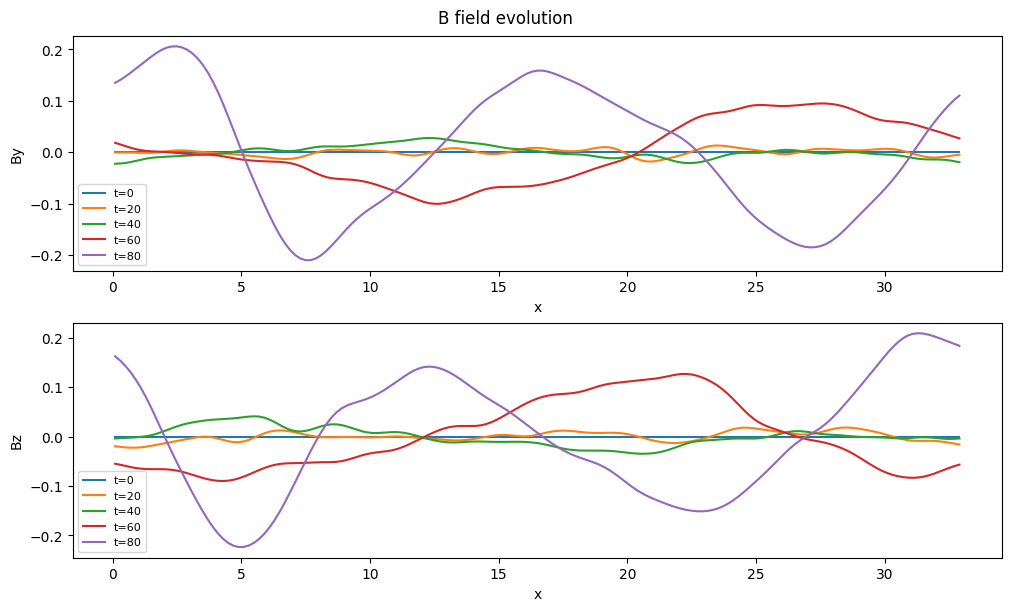

In [9]:
times_plot = np.arange(0, 100, 20)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
fig.suptitle("B field evolution")

for i, time in enumerate(times_plot):
    B = run.GetB(time, all_primal=False)
    b = phc.filters.gaussian(B, sigma=3)
    b.plot(qty='y', ax=axes[0], ls='solid', lw=1.5, color=colors[i % 10],
           label="t={:.0f}".format(time), ylabel='By')
    b.plot(qty='z', ax=axes[1], ls='solid', lw=1.5, color=colors[i % 10],
           label="t={:.0f}".format(time), ylabel='Bz')

for ax in axes:
    ax.legend(fontsize=8)
    ax.set_xlabel("x")

Text(0, 0.5, 'Vx - Velocity')

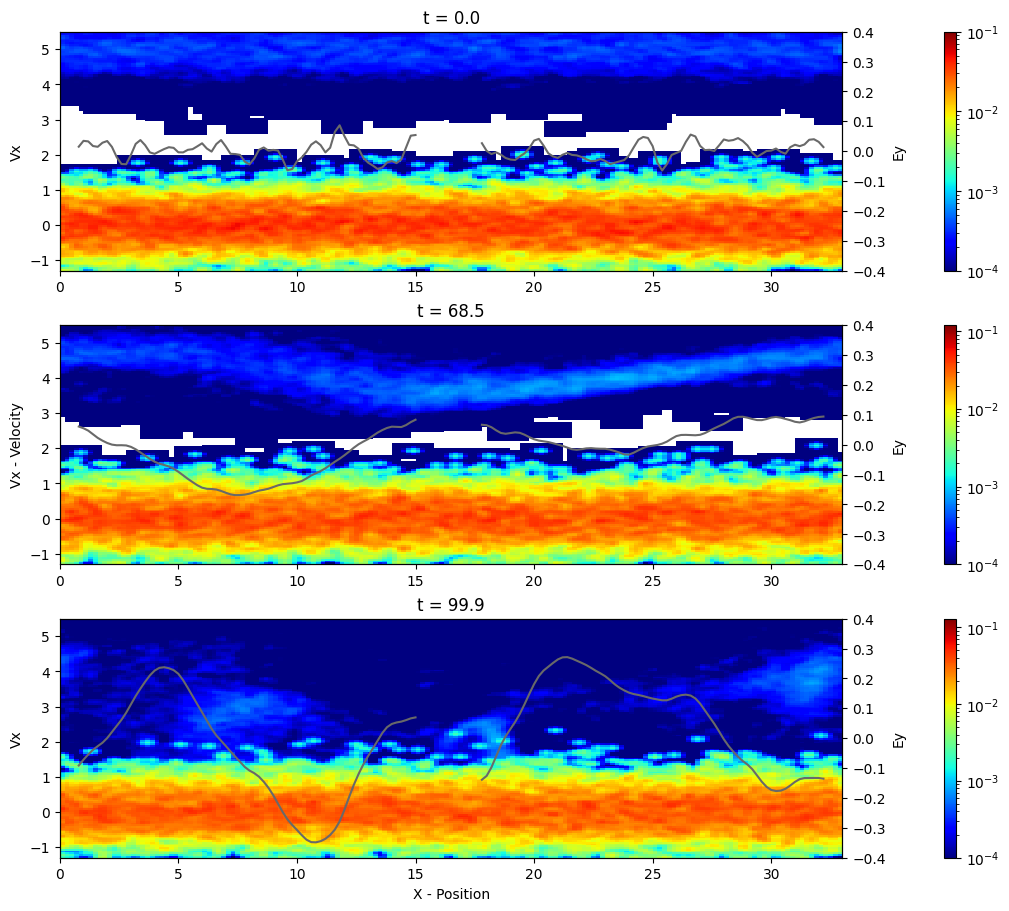

In [10]:
t_list = [0, times_all[imax], times_all[-1]]
fig, axes = plt.subplots(len(t_list), 1, figsize=(10, 9), constrained_layout=True)
vmin, vmax = -1.3, 5.6

for ax, t in zip(axes, t_list):
    ax_t = ax.twinx()

    ions = run.GetParticles(t, ["main", "beam"])
    ions.dist_plot(
        axis=("x", "Vx"),
        ax=ax,
        norm=0.4,
        finest=True,
        gaussian_filter_sigma=(1, 1),
        vmin=vmin,
        vmax=vmax,
        dv=0.05,
        title="t = {:.1f}".format(t),
        xlabel="",
        ylabel="Vx",
    )
    ax.set_xlim((0, 33))

    E = run.GetE(t)
    e = phc.filters.gaussian(E, sigma=1)
    e.plot(qty='y', ax=ax_t, lw=2, color="dimgray")
    ax_t.set_ylim((-0.4, 0.4))
    ax_t.set_ylabel("Ey")

axes[-1].set_xlabel("X - Position")
axes[len(t_list) // 2].set_ylabel("Vx - Velocity")